In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#style
sns.set(style = "whitegrid")

#Load dataset
df = pd.read_csv("../data/synthetic_fraud_dataset.csv")

df.head()
#First 5 rows

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [ ]:
df.shape
#rows(transcations), columns(features)

(10000, 10)

In [6]:
df.info

<bound method DataFrame.info of       transaction_id  user_id       amount transaction_type merchant_category  \
0               9608      363  4922.587542              ATM            Travel   
1                456      692    48.018303               QR              Food   
2               4747      587   136.881960           Online            Travel   
3               6934      445    80.534719              POS          Clothing   
4               1646      729   120.041158           Online           Grocery   
...              ...      ...          ...              ...               ...   
9995            1076      482    58.366442              POS          Clothing   
9996            4995      904   139.502160              POS            Travel   
9997            3485      527    71.012122           Online            Travel   
9998            7922      771    21.031405               QR           Grocery   
9999            6451      429    54.028632              ATM       Electronics

In [ ]:
df.isnull().sum()
#check if their is any missing values

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [8]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [9]:
df.columns

Index(['transaction_id', 'user_id', 'amount', 'transaction_type',
       'merchant_category', 'country', 'hour', 'device_risk_score',
       'ip_risk_score', 'is_fraud'],
      dtype='str')

In [ ]:
#1.) How many fraudlent charges do we have versus legitimate charges?

df['is_fraud'].value_counts(normalize=True)


is_fraud
0    0.95
1    0.05
Name: proportion, dtype: float64

Text(0.5, 0, 'Transaction Status')

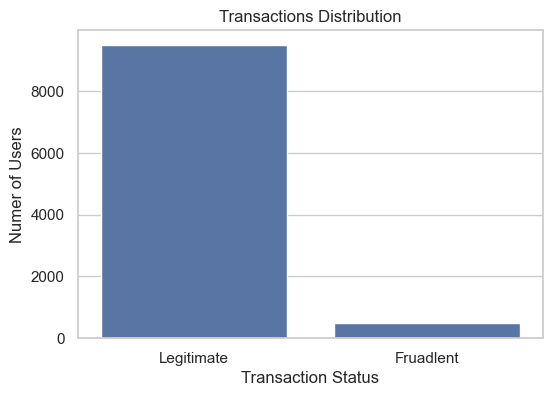

In [18]:
#Legitimate/Fraud Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)

plt.title("Transactions Distribution")
plt.xticks([0,1], ['Legitimate', 'Fruadlent'])
plt.ylabel("Numer of Users")
plt.xlabel("Transaction Status")

In [ ]:
#2.) Does fraud happen in large quantities or smaller quantities?

#Finds 5 rows with the highest value in 'amount'
top_row = df.nlargest(5, 'amount') [['amount', 'is_fraud']]
print("Top 5 Highest Fraudulent Transactions")
print(top_row)

#Finds 5 rows with the lowest value in 'amount'
bottom_row = df.nsmallest(5, 'amount') [['amount', 'is_fraud']]
print("\nTop 5 Lowest Transactions")
print(bottom_row)


Top 5 Highest Fraudulent Transactions
            amount  is_fraud
3590  11628.213881         1
6932  11085.081508         1
5680  10430.158835         1
2542   9647.703212         1
8093   8893.770032         1

Top 5 Lowest Transactions
     amount  is_fraud
28      1.0         0
91      1.0         0
170     1.0         0
179     1.0         0
248     1.0         0


In [ ]:
#Create bins
bins = [0, 500, 1000, 5000, 10000, 15000]
labels = ['<500', '501-1000', '1001-5000', '5001-10000', '10001-15000']

#Converting continuous numbers into categories
df['amount_bin'] = pd.cut(df['amount'], bins=bins, labels=labels)


#Transaction counts
#how many transactions falls into each category 
total_counts = df['amount_bin'].value_counts().sort_index()
fraud_counts = df[df['is_fraud'] == 1]['amount_bin'].value_counts().sort_index()


#Fraud rate
fraud_rate = fraud_counts / total_counts


#Amount calculations

#group transactions by amount range
#total fraud amount per bin
fraud_amount = df[df['is_fraud'] == 1].groupby('amount_bin')['amount'].sum()
#total legitimate amount per bin
legit_amount = df[df['is_fraud'] == 0].groupby('amount_bin')['amount'].sum()


#Combine into summary table
summary = pd.DataFrame({
    'Total Transactions': total_counts,
    'Fraud Transactions': fraud_counts,
    'Fraud Rate': fraud_rate,
    'Legitimate Amount ($)': legit_amount,
    'Fraud Amount ($)': fraud_amount
}).fillna(0)

# create total amount column
summary['Total Amount ($)'] = summary['Legitimate Amount ($)'] + summary['Fraud Amount ($)']

# reset index so amount bins show as column
summary = summary.reset_index()
summary.rename(columns={'index':'Amount Range'}, inplace=True)

# format money columns
summary['Legitimate Amount ($)'] = summary['Legitimate Amount ($)'].apply(lambda x: f"${x:,.2f}")
summary['Fraud Amount ($)'] = summary['Fraud Amount ($)'].apply(lambda x: f"${x:,.2f}")
summary['Total Amount ($)'] = summary['Total Amount ($)'].apply(lambda x: f"${x:,.2f}")

print(summary)




    amount_bin  Total Transactions  Fraud Transactions  Fraud Rate  \
0         <500                9663                 163    0.016868   
1     501-1000                  58                  58    1.000000   
2    1001-5000                 255                 255    1.000000   
3   5001-10000                  21                  21    1.000000   
4  10001-15000                   3                   3    1.000000   

  Legitimate Amount ($) Fraud Amount ($) Total Amount ($)  
0           $952,638.64        $9,530.30      $962,168.94  
1                 $0.00       $44,480.28       $44,480.28  
2                 $0.00      $604,006.98      $604,006.98  
3                 $0.00      $137,627.97      $137,627.97  
4                 $0.00       $33,143.45       $33,143.45  


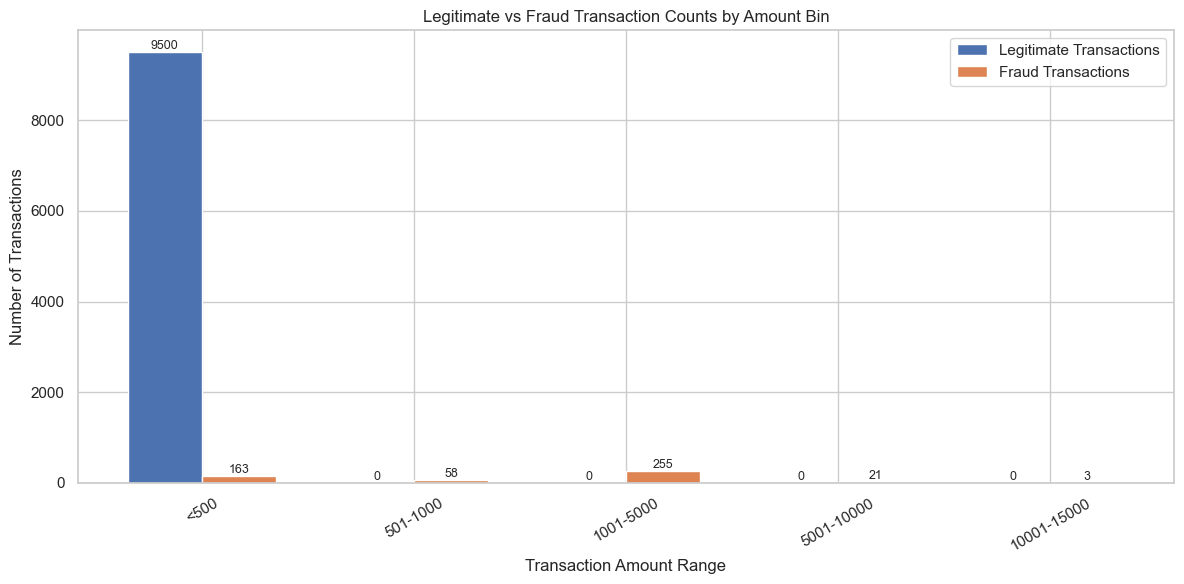

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Recalculate count data if needed
total_counts = df['amount_bin'].value_counts().sort_index()
fraud_counts = df[df['is_fraud'] == 1]['amount_bin'].value_counts().sort_index()
legit_counts = df[df['is_fraud'] == 0]['amount_bin'].value_counts().sort_index()

# Make sure missing bins are filled with 0
fraud_counts = fraud_counts.reindex(total_counts.index, fill_value=0)
legit_counts = legit_counts.reindex(total_counts.index, fill_value=0)

# X positions
x = np.arange(len(total_counts.index))
width = 0.35

# Create figure
plt.figure(figsize=(12, 6))

# Plot bars
bars1 = plt.bar(x - width/2, legit_counts.values, width, label='Legitimate Transactions')
bars2 = plt.bar(x + width/2, fraud_counts.values, width, label='Fraud Transactions')

# Labels and title
plt.xlabel('Transaction Amount Range')
plt.ylabel('Number of Transactions')
plt.title('Legitimate vs Fraud Transaction Counts by Amount Bin')
plt.xticks(x, total_counts.index, rotation=30)
plt.legend()

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#3.) What type of transaction is the biggest risk of fraud?

# total transactions per type
total_transactions = df.groupby('transaction_type').size()

# fraud transactions per type
fraud_transactions = df[df['is_fraud'] == 1].groupby('transaction_type').size()

# calculate fraud rate
fraud_rate = fraud_transactions / total_transactions

# combine into a table
transaction_type_summary = pd.DataFrame({
    'Total Transactions': total_transactions,
    'Fraud Transactions': fraud_transactions,
    'Fraud Rate': fraud_rate
}).fillna(0)


transaction_type_summary

,Total Transactions,Fraud Transactions,Fraud Rate
transaction_type,,,
ATM,2529,138,0.054567
Online,2397,126,0.052566
POS,2568,116,0.045171
QR,2506,120,0.047885


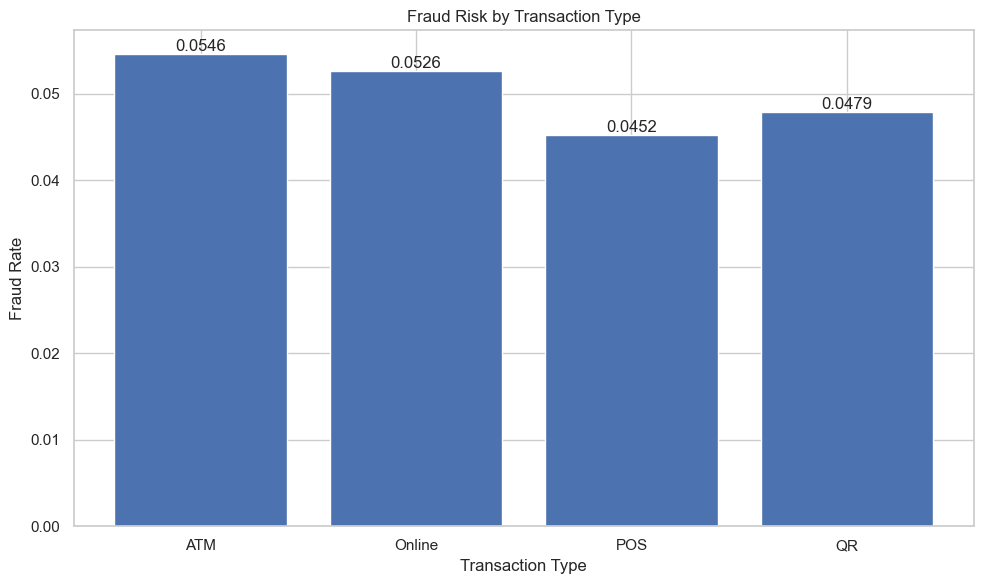

In [52]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(transaction_summary.index, transaction_summary['Fraud Rate'])

plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.title("Fraud Risk by Transaction Type")

# Show fraud rate labels with high precision
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [62]:
#4.) What are the most common fraudulent category purchases? 

# Total transactions per merchant category
total_category = df.groupby('merchant_category').size()

# Legitimate transactions per merchant category
legit_category = df[df['is_fraud'] == 0].groupby('merchant_category').size()

# Fraudulent transactions per merchant category
fraud_category = df[df['is_fraud'] == 1].groupby('merchant_category').size()

# Fraud rate per merchant category
fraud_rate_category = (fraud_category / total_category).fillna(0)

# Combine into one table
category_summary = pd.DataFrame({
    'Total Transactions': total_category,
    'Legitimate Transactions': legit_category,
    'Fraudulent Transactions': fraud_category,
    'Fraud Rate': fraud_rate_category
}).fillna(0)

# Clean formatting
category_summary = category_summary.reset_index()
category_summary.rename(columns={'merchant_category': 'Purchase Category'}, inplace=True)
category_summary['Fraud Rate'] = category_summary['Fraud Rate'].round(4)

# Sort by most fraudulent transactions
category_summary = category_summary.sort_values(by='Fraudulent Transactions', ascending=False)

print(category_summary)

  Purchase Category  Total Transactions  Legitimate Transactions  \
0          Clothing                1982                     1873   
4            Travel                2015                     1909   
1       Electronics                2007                     1909   
3           Grocery                1973                     1878   
2              Food                2023                     1931   

   Fraudulent Transactions  Fraud Rate  
0                      109      0.0550  
4                      106      0.0526  
1                       98      0.0488  
3                       95      0.0482  
2                       92      0.0455  


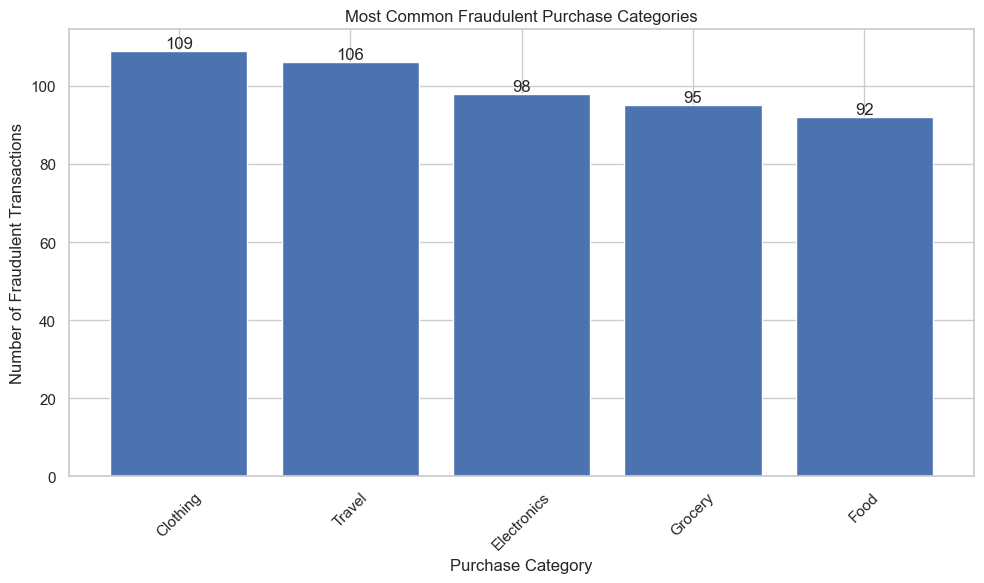

In [64]:
#Graph
plt.figure(figsize=(10,6))
bars = plt.bar(fraud_categories.index, fraud_categories.values)

plt.xlabel("Purchase Category")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Most Common Fraudulent Purchase Categories")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


In [71]:
#5.) What countries produce the most fraud?

# Total transactions per country
total_country = df.groupby('country').size()

# Legitimate transactions per country
legit_country = df[df['is_fraud'] == 0].groupby('country').size()

# Fraudulent transactions per country
fraud_country = df[df['is_fraud'] == 1].groupby('country').size()

# Fraud rate per country
fraud_rate_country = (fraud_country / total_country).fillna(0)

# Combine into one table
country_summary = pd.DataFrame({
    'Total Transactions': total_country,
    'Legitimate Transactions': legit_country,
    'Fraudulent Transactions': fraud_country,
    'Fraud Rate': fraud_rate_country
}).fillna(0)

# Clean formatting
country_summary = country_summary.reset_index()
country_summary.rename(columns={'country': 'Country'}, inplace=True)
country_summary['Fraud Rate'] = country_summary['Fraud Rate'].round(4)

# Sort by most fraudulent transactions
country_summary = country_summary.sort_values(by='Country')

print(country_summary)

  Country  Total Transactions  Legitimate Transactions  \
0      DE                1930                   1861.0   
1      FR                2027                   1953.0   
2      NG                 100                      0.0   
3      TR                1928                   1853.0   
4      UK                1965                   1880.0   
5      US                2050                   1953.0   

   Fraudulent Transactions  Fraud Rate  
0                       69      0.0358  
1                       74      0.0365  
2                      100      1.0000  
3                       75      0.0389  
4                       85      0.0433  
5                       97      0.0473  


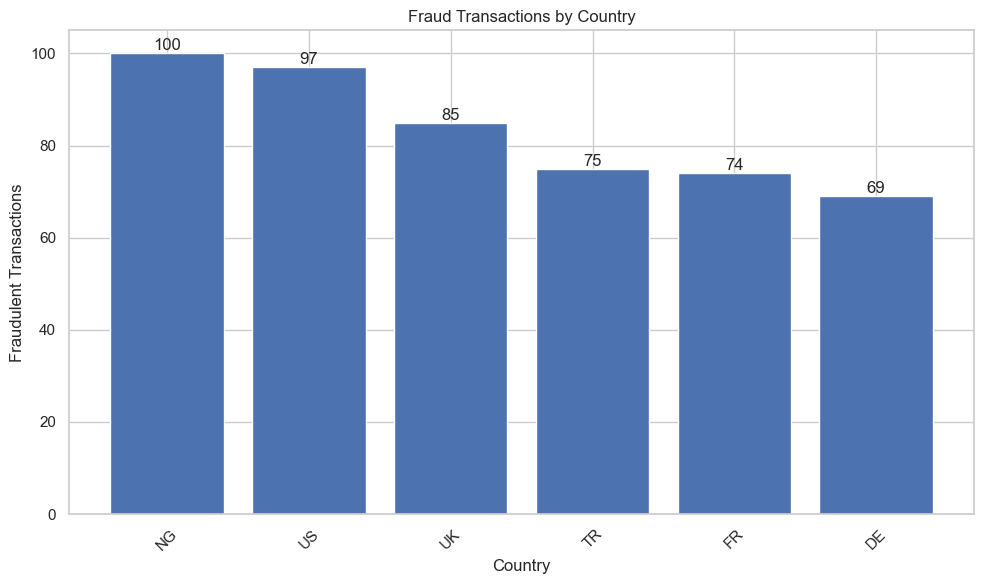

In [ ]:
#Graph

plt.figure(figsize=(10,6))
bars = plt.bar(fraud_countries.index, fraud_countries.values)

plt.xlabel("Country")
plt.ylabel("Fraudulent Transactions")
plt.title("Fraud Transactions by Country")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [69]:
#6.) Compare times at which fraudulent transactions occur?

# Total transactions by hour
total_hour = df.groupby('hour').size()

# Legitimate transactions by hour
legit_hour = df[df['is_fraud'] == 0].groupby('hour').size()

# Fraudulent transactions by hour
fraud_hour = df[df['is_fraud'] == 1].groupby('hour').size()

# Fraud rate by hour
fraud_rate_hour = (fraud_hour / total_hour).fillna(0)

# Combine into one table
hour_summary = pd.DataFrame({
    'Total Transactions': total_hour,
    'Legitimate Transactions': legit_hour,
    'Fraudulent Transactions': fraud_hour,
    'Fraud Rate': fraud_rate_hour
}).fillna(0)

# Clean formatting
hour_summary = hour_summary.reset_index()
hour_summary.rename(columns={'hour': 'Hour of Day'}, inplace=True)
hour_summary['Fraud Rate'] = hour_summary['Fraud Rate'].round(4)

# Sort by hour
hour_summary = hour_summary.sort_values(by='Hour of Day')

print(hour_summary)

    Hour of Day  Total Transactions  Legitimate Transactions  \
0             0                  16                      0.0   
1             1                  11                      0.0   
2             2                  16                      0.0   
3             3                  18                      0.0   
4             4                 117                      0.0   
5             5                  15                      0.0   
6             6                 560                    538.0   
7             7                 545                    530.0   
8             8                 530                    511.0   
9             9                 541                    526.0   
10           10                 560                    543.0   
11           11                 534                    515.0   
12           12                 541                    519.0   
13           13                 584                    561.0   
14           14                 522     

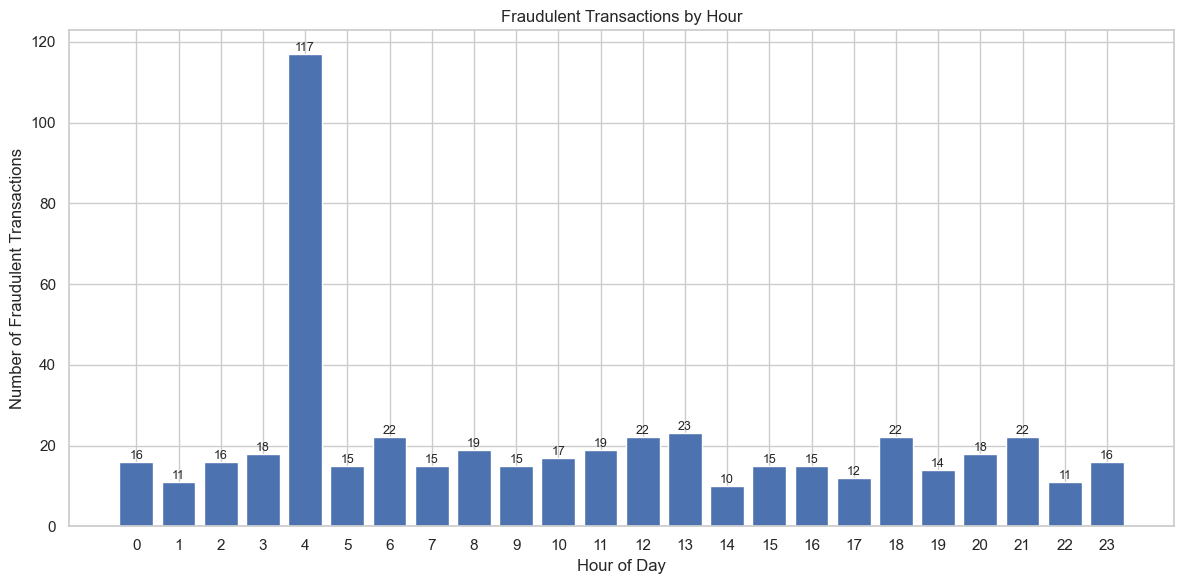

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.bar(hour_summary['Hour of Day'], hour_summary['Fraudulent Transactions'])

plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Fraudulent Transactions by Hour')
plt.xticks(hour_summary['Hour of Day'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()